# Proyecto Deep Learning Spotify: Tarea 3 - Modelo 5: Red ancha

## Configuración del entorno

In [ ]:
%pip install -r ../requirements.txt

In [ ]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.callbacks import EarlyStopping


sys.path.append(os.path.abspath('..'))
from models.T3_M5_red_ancha import crear_modelo

In [2]:
df = pd.read_csv(r'..\data\data.csv')

df_limpio = df[
    (df['duration_ms'] > 40000) & 
    (df['speechiness'] < 0.90) & 
    (df['tempo'] > 0)
].copy()

cols_to_drop = ['popularity', 'id', 'name', 'artists', 'id_artists', 'release_date', 'mode']
X = df_limpio.drop(columns=cols_to_drop, errors='ignore')
y = df_limpio['popularity']

In [3]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [4]:
modelo_nn = crear_modelo(X_train_scaled.shape[1])

print("RESUMEN DE LA ARQUITECTURA (NÚMERO DE PARÁMETROS)")
modelo_nn.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True
)

historia = modelo_nn.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=500,
    batch_size=64,
    verbose=1,
    callbacks=[early_stop]
)

RESUMEN DE LA ARQUITECTURA (NÚMERO DE PARÁMETROS)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141,825 (554.00 KB)

 Trainable params: 140,289 (548.00 KB)

 Non-trainable params: 1,536 (6.00 KB)

Epoch 1/500
1816/1816 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 237.3420 - mae: 11.2436 - val_loss: 105.5413 - val_mae: 7.3872
Epoch 2/500
1816/1816 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 121.8446 - mae: 8.2065 - val_loss: 103.3135 - val_mae: 7.1367
Epoch 3/500
1816/1816 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 118.1282 - mae: 8.0363 - val_loss: 102.2393 - val_mae: 7.0759
Epoch 4/500
1816/1816 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 115.9103 - mae: 7.9460 - val_loss: 101.7002 - val_mae: 7.2534
Epoch 5/500
1816/1816 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 115.6816 - mae: 7.9336 - val_loss: 102.8921 - val_mae: 7.4245
Epoch 6/500
1816/1816 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 114.0278 - mae: 7.8474 - val_loss: 100.5848 - val_mae: 7.1133
Epoch 7/500
1816/1816 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 113.4163 - mae: 7.8362 - val_loss: 99.9800 - val_mae: 7.0415
Epoch 8/500
1816/1816 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 113.0650 - mae: 7.8144 - val_loss: 99.4514 - val_mae: 7.0935
E

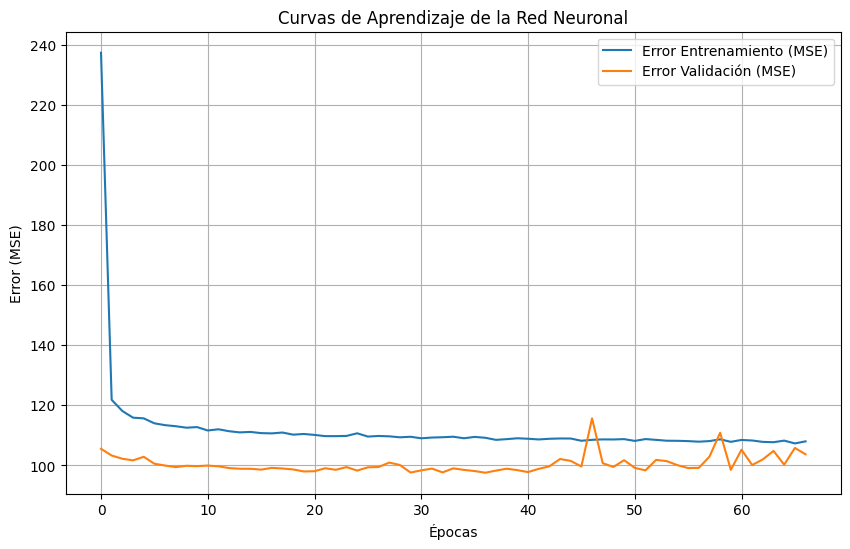

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(historia.history['loss'], label='Error Entrenamiento (MSE)')
plt.plot(historia.history['val_loss'], label='Error Validación (MSE)')
plt.title('Curvas de Aprendizaje de la Red Neuronal')
plt.xlabel('Épocas')
plt.ylabel('Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
def evaluar_red(modelo, X_data, y_true, nombre_conjunto):
    y_pred = modelo.predict(X_data, verbose=0).flatten()
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- Resultados en {nombre_conjunto} ---")
    print(f"MSE:  {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²:   {r2:.4f}\n")

print("EVALUACIÓN RED NEURONAL\n")

evaluar_red(modelo_nn, X_train_scaled, y_train, "ENTRENAMIENTO")
evaluar_red(modelo_nn, X_val_scaled, y_val, "VALIDACIÓN")
evaluar_red(modelo_nn, X_test_scaled, y_test, "TEST")

EVALUACIÓN RED NEURONAL

--- Resultados en ENTRENAMIENTO ---
MSE:  97.36
RMSE: 9.87
R²:   0.7908

--- Resultados en VALIDACIÓN ---
MSE:  97.59
RMSE: 9.88
R²:   0.7911

--- Resultados en TEST ---
MSE:  93.36
RMSE: 9.66
R²:   0.7973

